## LECTURA Y PREPROCESAMIENTO

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import geemap, ee
from shapely.geometry import Point
from shapely.ops import transform, nearest_points
from sklearn.cluster import DBSCAN
from libpysal.weights import Queen
from esda.moran import Moran_Local
import pyproj
from tqdm import tqdm
import matplotlib.patches as mpatches


from warnings import filterwarnings
filterwarnings("ignore")

# Autenticación e inicialización Earth Engine
ee.Authenticate()
ee.Initialize()

# Limites de Santiago Urbano
stgo = gpd.read_file("Datos/santiago_urbano.gpkg")
roi_shapely = stgo.union_all()

# Limite comunal (intersectado con Santiago Urbano)
Limite_Comunal = gpd.read_file("Datos/Limite_Comunal.gpkg")
Limite_Comunal['geometry'] = Limite_Comunal.geometry.intersection(roi_shapely)
Limite_Comunal = Limite_Comunal[~Limite_Comunal.is_empty]

# Zonas censales
zonas = gpd.read_file("Datos/datosZonas_Stgo_C2017.gpkg").to_crs(Limite_Comunal.crs)
zonas['centroide'] = zonas.geometry.centroid
zonas_centros = zonas.set_geometry('centroide')
zonas_centros = zonas_centros.sjoin(Limite_Comunal[['comuna', 'geometry']], how='left', predicate='within')
zonas['comuna'] = zonas_centros['comuna'].values


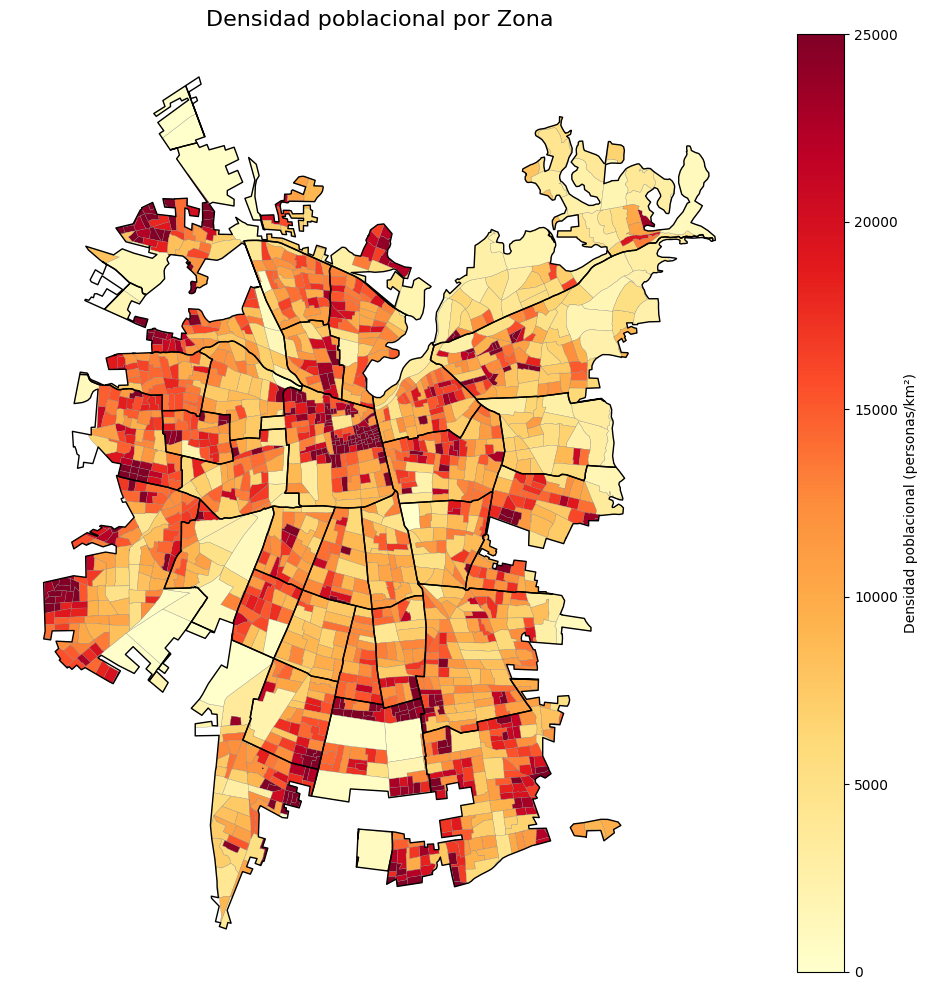

In [2]:
# Calcular área y densidad poblacional
zonas_proj = zonas.to_crs(epsg=32719)
zonas['area_km2'] = zonas_proj.geometry.area / 1e6
zonas['densidad'] = zonas['PERSONAS'] / zonas['area_km2']

# Visualización: densidad poblacional
fig, ax = plt.subplots(figsize=(10, 10))
vmax = 25000
zonas.plot(
    column='densidad', ax=ax, cmap='YlOrRd', legend=True, 
    legend_kwds={'label': "Densidad poblacional (personas/km²)"},
    edgecolor='gray', linewidth=0.2, vmax=vmax)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title('Densidad poblacional por Zona', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

## Red de Metro Actual y Covertura

In [3]:
# Plot Red de Metro
df = pd.read_csv("Datos/estaciones_metro.csv", decimal=',')
df['stop_lat'] = df['stop_lat'].astype(str).str.replace(',', '.').astype(float)
df['stop_lon'] = df['stop_lon'].astype(str).str.replace(',', '.').astype(float)
df['geometry'] = df.apply(lambda row: Point(row['stop_lon'], row['stop_lat']), axis=1)
gdf_estaciones = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Leer líneas del metro y visualización en geemap
lineas_metro = gpd.read_file("Datos/lineas_metro.gpkg", layer="lineas")

m = geemap.Map(center=[-33.45, -70.65], zoom=12)
# Agregar Santiago urbano
m.add_gdf(stgo, layer_name="Santiago Urbano", style={"color": "black", "weight": 2, "fillOpacity": 0.05})

# Agregar límite comunal
m.add_gdf(Limite_Comunal, layer_name="Límite Comunal", style={"color": "gray", "weight": 1, "fillOpacity": 0.2})

for _, row in lineas_metro.iterrows():
    m.add_gdf(
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326"),
        layer_name=f"Línea {row['linea']}",
        style={"color": row["color"], "weight": 4}
    )
m

Map(center=[-33.45, -70.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…

## Cobertura Actual Metro

In [4]:
# Crear buffer de 1 km alrededor de estaciones
estaciones_proj = gdf_estaciones.to_crs(epsg=32719)
buffer_1km = estaciones_proj.buffer(1000)
buffer_union = buffer_1km.unary_union

# Volver a WGS84 para intersectar
project_back = pyproj.Transformer.from_crs(32719, 4326, always_xy=True).transform
buffer_1km_wgs = gpd.GeoSeries([transform(project_back, buffer_union)], crs="EPSG:4326")

# Determinar cobertura
zonas['cerca_metro'] = zonas.geometry.intersects(buffer_1km_wgs.iloc[0]).astype(int)

# Análisis espacial con clusters de Moran Local
w_zonas = Queen.from_dataframe(zonas)
moran_local = Moran_Local(zonas['cerca_metro'], w_zonas)

zonas['cluster_metro'] = 'No significativo'
zonas.loc[(moran_local.q == 1) & (moran_local.p_sim < 0.05), 'cluster_metro'] = 'Alto-Alto'
zonas.loc[(moran_local.q == 2) & (moran_local.p_sim < 0.05), 'cluster_metro'] = 'Bajo-Alto'
zonas.loc[(moran_local.q == 3) & (moran_local.p_sim < 0.05), 'cluster_metro'] = 'Bajo-Bajo'
zonas.loc[(moran_local.q == 4) & (moran_local.p_sim < 0.05), 'cluster_metro'] = 'Alto-Bajo'


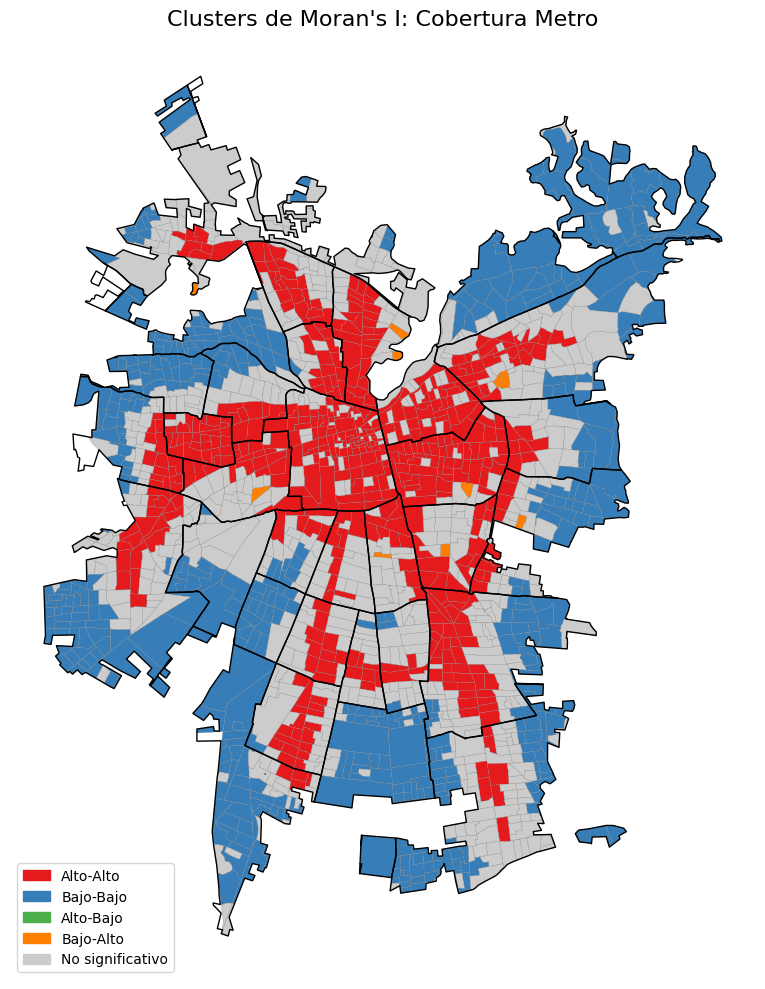

In [5]:
cluster_colors = {
    'Alto-Alto': '#e41a1c',
    'Bajo-Bajo': '#377eb8',
    'Alto-Bajo': '#4daf4a',
    'Bajo-Alto': '#ff7f00',
    'No significativo': '#cccccc'
}

fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, color=zonas['cluster_metro'].map(cluster_colors), edgecolor='gray', linewidth=0.2)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Clusters de Moran's I: Cobertura Metro", fontsize=16)
ax.axis('off')

legend_patches = [mpatches.Patch(color=color, label=label) for label, color in cluster_colors.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

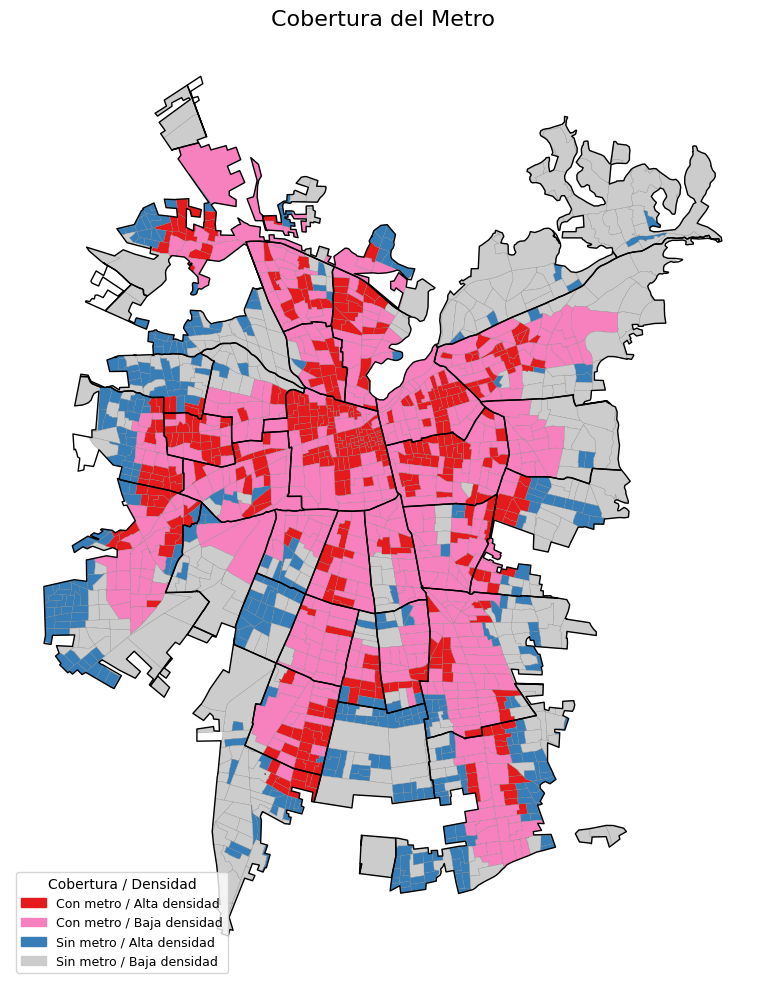

In [6]:
# Clasificación según cuartiles de densidad
zonas['dens_q'] = pd.qcut(zonas['densidad'], 2, labels=['Baja densidad', 'Alta densidad'])
zonas['metro_q'] = zonas['cerca_metro'].map({0: 'Sin metro', 1: 'Con metro'})
zonas['combo'] = zonas['metro_q'].astype(str) + " / " + zonas['dens_q'].astype(str)

# Visualización de zonas críticas combinadas
palette_combo = {
    'Con metro / Alta densidad': '#e41a1c',
    'Con metro / Baja densidad': '#f781bf',
    'Sin metro / Alta densidad': '#377eb8',
    'Sin metro / Baja densidad': '#cccccc'
}

fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, color=zonas['combo'].map(palette_combo), edgecolor='gray', linewidth=0.2)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Cobertura del Metro", fontsize=16)
ax.axis('off')

legend_patches = [mpatches.Patch(color=color, label=label) for label, color in palette_combo.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, title='Cobertura / Densidad')

plt.tight_layout()
plt.show()

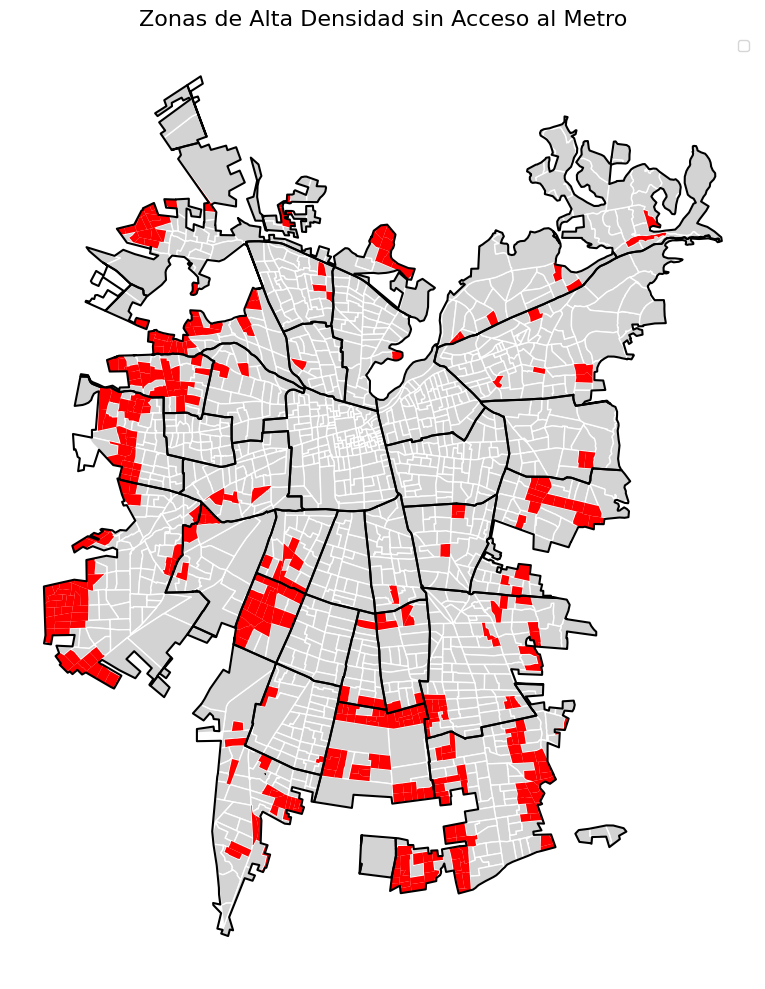

Cantidad de personas en zonas de alta densidad sin metro: 1,520,095


In [ ]:
# Identificar zonas críticas (alta densidad sin metro)
zonas['centroide'] = zonas.geometry.centroid
zonas_criticas = zonas[(zonas['dens_q'] == 'Alta densidad') & (zonas['cerca_metro'] == 0)]

# Visualización de zonas críticas
fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='white')
zonas_criticas.plot(ax=ax, color='red', markersize=30, label='Alta densidad sin cobertura')
Limite_Comunal.boundary.plot(ax=ax, color='black')

ax.set_title("Zonas de Alta Densidad sin Acceso al Metro", fontsize=16)
ax.legend()
ax.axis('off')
plt.tight_layout()
plt.show()
                                                                                                                                                                
# Población afectada en zonas críticas
total_personas_zonas_criticas = zonas_criticas['PERSONAS'].sum()
print(f"Cantidad de personas en zonas de alta densidad sin metro: {total_personas_zonas_criticas:,}")


## Nuevas Lineas

In [12]:
lineas_metro = gpd.read_file("Datos/nuevas_lineas_metro.gpkg", layer="lineas")

df_nuevas = pd.read_csv("Datos/nuevas_estaciones.csv")
# Crear mapa centrado en Santiago
m = geemap.Map(center=[-33.45, -70.65], zoom=12)

m.add_gdf(stgo, layer_name="Santiago Urbano", style={"color": "black", "weight": 2, "fillOpacity": 0.05})

# Agregar límite comunal
m.add_gdf(Limite_Comunal, layer_name="Límite Comunal", style={"color": "gray", "weight": 1, "fillOpacity": 0.2})

# Agregar cada línea al mapa con su color y estilo
for _, row in lineas_metro.iterrows():
    m.add_gdf(
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326"),
        layer_name=f"Línea {row['linea']}",
        style={"color": row["color"], "weight": 4}
    )

m

Map(center=[-33.45, -70.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…

## Img Satelitales

In [ ]:
gran_santiago = ee.Geometry.Polygon([
    [[-70.9, -33.8], [-70.9, -33.2], [-70.3, -33.2], [-70.3, -33.8]]
])

def mask_s2_sr_clouds(image):
    cloud_prob = image.select('MSK_CLDPRB')
    cloud_mask = cloud_prob.lt(20)
    return image.updateMask(cloud_mask).copyProperties(image, ["system:time_start"])

def get_annual_composite(year):
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(start_date, end_date)
        .filterBounds(gran_santiago)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2_sr_clouds)
    )
    count = collection.size().getInfo()
    if count == 0:
        print(f"No hay imágenes para el año {year}")
        return None
    return collection.median().clip(gran_santiago)

def ndvi(image):
    return image.normalizedDifference(['B8', 'B4']).rename('NDVI')

def ndbi(image):
    return image.normalizedDifference(['B11', 'B8']).rename('NDBI')

def get_ndvi_ndbi(year):
    img = get_annual_composite(year)
    if img:
        return img.addBands(ndvi(img)).addBands(ndbi(img))
    return None

img_2019 = get_ndvi_ndbi(2019)
img_2024 = get_ndvi_ndbi(2024)

ndvi_diff = img_2024.select('NDVI').subtract(img_2019.select('NDVI')).rename('NDVI_Diff')
ndbi_diff = img_2024.select('NDBI').subtract(img_2019.select('NDBI')).rename('NDBI_Diff')
diff_stack = ndvi_diff.addBands(ndbi_diff)

In [32]:
limite_comunal_ee = geemap.geopandas_to_ee(Limite_Comunal)

zonales_comunas = diff_stack.reduceRegions(
    collection=limite_comunal_ee,
    reducer=ee.Reducer.mean(),
    scale=30
)

Map = geemap.Map(center=[-33.45, -70.65], zoom=11)


vis_params = {
    'min': -0.5,
    'max': 0.5,
    'palette': [
        '006837', '1a9850', '66bd63', '000000', 'f46d43', 'd73027', 'a50026'
    ]
}

Map.addLayer(ndbi_diff, vis_params, 'Cambio NDBI 2019–2024')
Map.add_gdf(Limite_Comunal.boundary, layer_name='Límites comunales', style={'color': 'white', 'weight': 0.5})
Map.addLayerControl()

Map.add_gdf(stgo, layer_name="Santiago Urbano", style={"color": "white", "weight": 2})

Map

Map(center=[-33.45, -70.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…

In [30]:
def get_viirs_annual_mean(year):
    collection = (
        ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .select('avg_rad')
        .filterBounds(gran_santiago)
    )
    return collection.mean().clip(gran_santiago)

viirs_2018 = get_viirs_annual_mean(2017)
viirs_2024 = get_viirs_annual_mean(2024)

viirs_diff = viirs_2024.subtract(viirs_2018).rename('DIF_VIIRS')


viirs_vis = {
    'min': -5,
    'max': 20,
    'palette': ['000000', '440154', '31688e', '35b779', 'fde725']
}


Map = geemap.Map(center=[-33.45, -70.65], zoom=11)
Map.addLayer(viirs_diff, viirs_vis, 'Cambio Iluminación Nocturna (2018–2024)')
Map.addLayerControl()
Map.add_gdf(Limite_Comunal.boundary, layer_name='Límites comunales', style={'color': 'black', 'weight': 1.5})

Map.add_gdf(stgo, layer_name="Santiago Urbano", style={"color": "black", "weight": 4})

Map

Map(center=[-33.45, -70.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…